# 8.3 梯度下降与优化方法

> **课时**：2课时 | **难度**：⭐⭐⭐⭐ | **竞赛重要度**：⭐⭐⭐⭐⭐

## 📚 学习目标

1. 理解批量梯度下降、随机梯度下降、小批量梯度降的区别
2. 了解局部最优、鞍点、梯度消失/爆炸问题
3. 掌握动量法（Momentum）的原理
4. 掌握 Adam 优化器的原理（Momentum + RMSprop）
5. 了解 AdamW 优化器的改进
6. 理解学习率调度策略
7. 通过可视化对比不同优化方法的效果

---

## 1. 梯度下降的三种变体

### 1.1 基本思想

梯度下降通过沿梯度的**反方向**迭代更新参数，最小化损失函数：

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta L(\theta_t)$$

其中 $\eta$ 是**学习率**（learning rate）。

### 1.2 三种变体对比

| 方法 | 公式 | 每次使用样本数 | 优点 | 缺点 |
|------|------|:-----------:|------|------|
| **批量梯度下降（BGD）** | $\theta \leftarrow \theta - \eta \cdot \frac{1}{N}\sum_{i=1}^{N}\nabla L_i(\theta)$ | 全部 $N$ | 梯度准确 | 计算慢，内存大 |
| **随机梯度下降（SGD）** | $\theta \leftarrow \theta - \eta \cdot \nabla L_i(\theta)$ | 1 个 | 速度快，可跳出局部最优 | 梯度噪声大，不稳定 |
| **小批量梯度下降（Mini-batch GD）** | $\theta \leftarrow \theta - \eta \cdot \frac{1}{B}\sum_{i\in batch}\nabla L_i(\theta)$ | $B$ 个（通常 32~256） | 兼顾速度与稳定 | 需调超参数 $B$ |

### 1.3 小批量梯度下降（最常用）

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{1}{|B_t|}\sum_{i \in B_t} \nabla L_i(\theta_t)$$

其中 $B_t$ 是第 $t$ 步随机抽取的小批量样本集合。

> **实践中**：Mini-batch GD 是训练神经网络的**标准方法**，它在梯度估计的准确性和计算效率之间取得了良好的平衡。

---

## 2. 优化中的挑战

### 2.1 局部最优 vs 全局最优

**损失函数地形**可能非常复杂，包含：

| 概念 | 描述 | 示意图 |
|------|------|--------|
| **全局最小值** | 损失函数的最小值 | 地形最低点 |
| **局部最小值** | 某个区域内的最小值，但不是全局最小 | 盆地中的低洼 |
| **鞍点** | 某些方向是最小值，另一些方向是最大值 | 马鞍形状 |
| **平坦区域** | 梯度接近零的区域，收敛缓慢 | 高原 |

### 2.2 鞍点问题

在高维空间中，**鞍点的数量远多于局部最小值**。鞍点之所以成为问题，是因为：

$$\nabla L(\theta) = \mathbf{0}$$

在鞍点处梯度为零，梯度下降会"卡住"。

> **好消息**：动量法和自适应优化器可以帮助"冲过"鞍点。

### 2.3 梯度消失与梯度爆炸

**梯度消失**：

当网络很深时，梯度在反向传播中逐层缩小：

$$\frac{\partial L}{\partial W^{(1)}} \propto \prod_{l=1}^{L-1} f'(z^{(l)}) \cdot W^{(l)}$$

如果 $|f'(z)| < 1$ 且 $|W| < 1$，乘积指数级缩小 → 梯度消失。

**梯度爆炸**：

如果 $|W| > 1$，乘积指数级放大 → 梯度爆炸。

| 问题 | 原因 | 解决方法 |
|------|------|---------|
| 梯度消失 | 激活函数导数太小，权重太小 | ReLU、残差连接、合理初始化 |
| 梯度爆炸 | 权重太大，深层网络 | 梯度裁剪、权重正则化 |

---

## 3. 动量法（Momentum）

### 3.1 核心思想

在物理学中，小球滚下山坡时会积累"动量"，不仅受当前坡度影响，还受之前速度的影响。动量法模拟了这一过程。

### 3.2 数学公式

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \eta \cdot \nabla_\theta L(\theta_t)$$
$$\theta_{t+1} = \theta_t - \mathbf{v}_t$$

其中：
- $\mathbf{v}_t$ 是第 $t$ 步的**速度**（velocity）
- $\beta$ 是**动量系数**（通常取 0.9）
- $\eta$ 是学习率

### 3.3 动量法的优势

| 优势 | 解释 |
|------|------|
| **加速收敛** | 在一致的方向上积累速度 |
| **抑制震荡** | 在梯度方向频繁变化的维度上互相抵消 |
| **冲出局部最优** | 积累的动量可能越过局部最小值 |

> **类比**：普通 SGD 像一个人在雾中每步只看脚下；Momentum 像一个人有了惯性，可以"滑过"小坑。

---

## 4. Adam 优化器

### 4.1 概述

Adam（**Ad**aptive **M**oment Estimation）结合了 **Momentum** 和 **RMSprop** 的优点，是目前最常用的优化器。

### 4.2 算法步骤

**第一步：计算梯度**

$$\mathbf{g}_t = \nabla_\theta L(\theta_t)$$

**第二步：更新一阶矩估计（Momentum 部分）**

$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t$$

**第三步：更新二阶矩估计（RMSprop 部分）**

$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2$$

**第四步：偏差校正**

$$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}, \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}$$

**第五步：参数更新**

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t$$

### 4.3 参数说明

| 参数 | 符号 | 默认值 | 含义 |
|------|------|:------:|------|
| 学习率 | $\eta$ | 0.001 | 控制更新步长 |
| 一阶矩衰减率 | $\beta_1$ | 0.9 | 控制动量（类似 Momentum 的 $\beta$） |
| 二阶矩衰减率 | $\beta_2$ | 0.999 | 控制梯度平方的移动平均 |
| 数值稳定项 | $\epsilon$ | $10^{-8}$ | 防止除以零 |

### 4.4 Adam 的直观理解

$$\text{有效学习率}_i = \frac{\eta}{\sqrt{\hat{v}_{t,i}} + \epsilon}$$

- **梯度大的参数**：$v_i$ 大 → 有效学习率**减小**（自动降低步长）
- **梯度小的参数**：$v_i$ 小 → 有效学习率**增大**（自动增加步长）
- **效果**：每个参数都有自适应的学习率

---

## 5. AdamW 优化器

### 5.1 Adam 的改进

AdamW（Adam with **Weight Decay**）将权重衰减（L2 正则化）从梯度更新中**解耦**出来：

**标准 Adam + L2**（有问题）：

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon}\left(\hat{m}_t + \lambda \theta_t\right)$$

**AdamW**（正确方式）：

$$\theta_{t+1} = (1 - \eta \lambda)\theta_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon}\hat{m}_t$$

### 5.2 为什么要解耦？

在自适应学习率优化器中，L2 正则化项被自适应学习率缩放，导致正则化效果不一致。AdamW 直接对参数进行衰减，保证了正则化的正确性。

> **AdamW** 是目前训练大语言模型（如 GPT、BERT）的**标准优化器**。

---

## 6. 学习率调度策略

### 6.1 为什么需要学习率调度？

训练过程中，不同阶段对学习率的需求不同：
- **初期**：需要较大学习率快速收敛
- **中期**：需要减小学习率精细调整
- **后期**：需要很小学习率稳定到最优

### 6.2 常用策略

**StepLR（阶梯衰减）**：

$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / T \rfloor}$$

每 $T$ 步将学习率乘以 $\gamma$（通常 $\gamma = 0.1$）。

**CosineAnnealingLR（余弦退火）**：

$$\eta_t = \eta_{\min} + \frac{\eta_{\max} - \eta_{\min}}{2}\left(1 + \cos\left(\frac{t}{T_{\max}}\pi\right)\right)$$

学习率按余弦函数平滑衰减。

**Warmup（预热）+ 衰减**：

先线性增大学习率（warmup 阶段），再按照余弦衰减。

$$\eta_t = \begin{cases} \eta_{\max} \cdot t / T_{\text{warmup}}, & t < T_{\text{warmup}} \\ \text{衰减策略}(t), & t \geq T_{\text{warmup}} \end{cases}$$

### 6.3 策略对比

| 策略 | 优点 | 缺点 | 适用场景 |
|------|------|------|---------|
| StepLR | 简单 | 不够平滑 | 传统 CV 任务 |
| CosineAnnealing | 平滑衰减 | 需设 $T_{\max}$ | NLP、大模型 |
| Warmup+Cosine | 先热身后衰减 | 复杂 | Transformer 训练 |

---

## 7. 竞赛考点总结

| 考点 | 重要程度 |
|------|---------|
| BGD/SGD/Mini-batch GD 的区别 | ⭐⭐⭐⭐⭐ |
| 动量法的公式与原理 | ⭐⭐⭐⭐⭐ |
| Adam 算法的完整步骤 | ⭐⭐⭐⭐⭐ |
| Adam 的偏差校正 | ⭐⭐⭐⭐ |
| 梯度消失/爆炸 | ⭐⭐⭐⭐⭐ |
| 学习率调度策略 | ⭐⭐⭐⭐ |
| AdamW 与 Adam 的区别 | ⭐⭐⭐ |


## 8. 代码实战

### 8.1 可视化三种梯度下降的收敛路径

In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'STSong', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 定义一个二维损失函数 (Rosenbrock 函数变体)
# ============================================

def loss_function(w1, w2):
    """Beale 函数（用于可视化）"""
    return (1.5 - w1 + w1*w2)**2 + (2.25 - w1 + w1*w2**2)**2 + (2.625 - w1 + w1*w2**3)**2

def gradient(w1, w2):
    """数值梯度"""
    eps = 1e-7
    dw1 = (loss_function(w1+eps, w2) - loss_function(w1-eps, w2)) / (2*eps)
    dw2 = (loss_function(w1, w2+eps) - loss_function(w1, w2-eps)) / (2*eps)
    return np.array([dw1, dw2])

# ============================================
# 三种梯度下降实现
# ============================================

def gradient_descent(lr, method='bgd', epochs=100, batch_size=None):
    """
    梯度下降
    method: 'bgd', 'sgd', 'mini-batch'
    """
    w = np.array([-3.0, 3.0])  # 初始点
    history = [w.copy()]
    
    for epoch in range(epochs):
        if method == 'bgd':
            # 使用全部"数据"（此处为确定性格度）
            grad = gradient(w[0], w[1])
        elif method == 'sgd':
            # 添加噪声模拟单个样本
            grad = gradient(w[0], w[1]) + np.random.randn(2) * 2.0
        elif method == 'mini-batch':
            # 添加较小噪声模拟小批量
            grad = gradient(w[0], w[1]) + np.random.randn(2) * 0.5
        
        w = w - lr * grad
        history.append(w.copy())
    
    return np.array(history)

# 运行三种方法
np.random.seed(42)
history_bgd = gradient_descent(lr=0.00003, method='bgd', epochs=80)
history_sgd = gradient_descent(lr=0.00003, method='sgd', epochs=80)
history_minibatch = gradient_descent(lr=0.00003, method='mini-batch', epochs=80)

print("三种梯度下降方法运行完毕！")
print(f"  BGD 最终位置: ({history_bgd[-1,0]:.3f}, {history_bgd[-1,1]:.3f})")
print(f"  SGD 最终位置: ({history_sgd[-1,0]:.3f}, {history_sgd[-1,1]:.3f})")
print(f"  Mini-batch 最终位置: ({history_minibatch[-1,0]:.3f}, {history_minibatch[-1,1]:.3f})")

三种梯度下降方法运行完毕！
  BGD 最终位置: (-2.606, 1.410)
  SGD 最终位置: (-2.605, 1.410)
  Mini-batch 最终位置: (-2.606, 1.410)


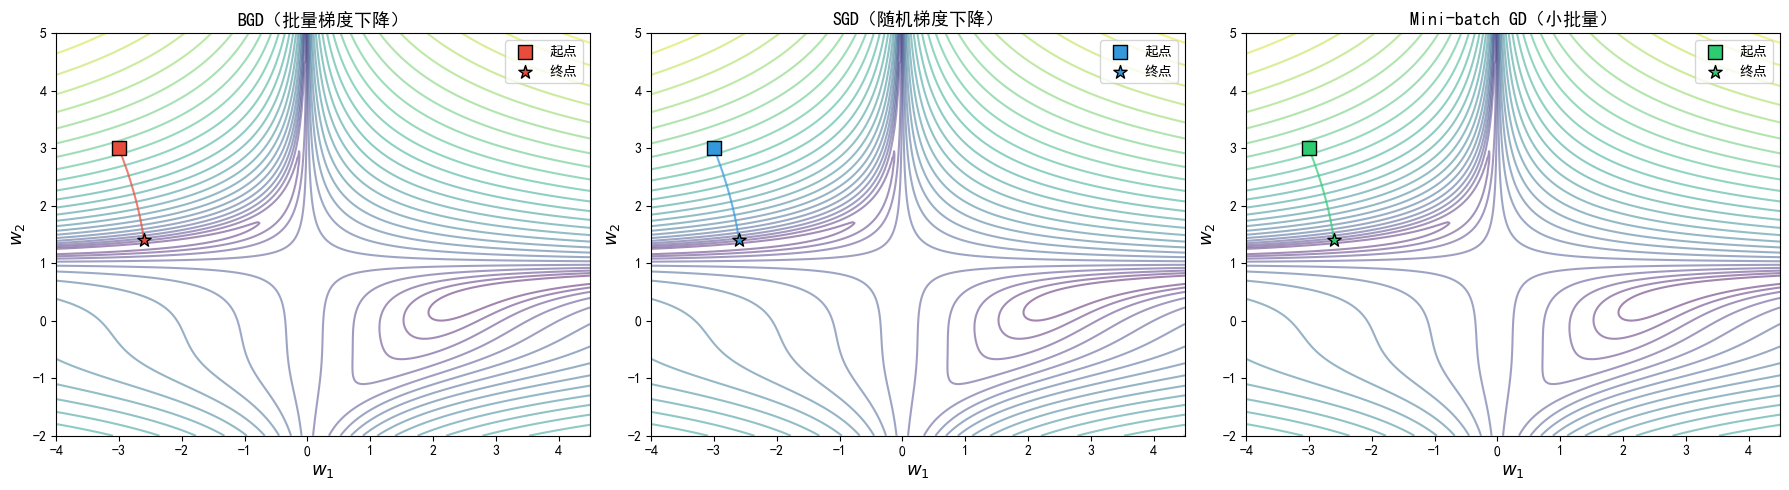

观察要点:
  - BGD 路径平滑，但可能缓慢
  - SGD 路径抖动，但有机会跳出局部最优
  - Mini-batch 介于两者之间，是最实用的选择


In [12]:
# ============================================
# 可视化收敛路径
# ============================================

# 创建损失函数等高线
w1_range = np.linspace(-4, 4.5, 300)
w2_range = np.linspace(-2, 5, 300)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = loss_function(W1, W2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('BGD（批量梯度下降）', history_bgd, '#e74c3c'),
    ('SGD（随机梯度下降）', history_sgd, '#3498db'),
    ('Mini-batch GD（小批量）', history_minibatch, '#2ecc71')
]

for ax, (title, history, color) in zip(axes, methods):
    # 等高线
    ax.contour(W1, W2, np.log1p(L), levels=30, cmap='viridis', alpha=0.5)
    
    # 收敛路径
    ax.plot(history[:, 0], history[:, 1], '-', color=color, linewidth=1.5, alpha=0.7)
    ax.scatter(history[0, 0], history[0, 1], c=color, s=100, marker='s', 
               edgecolors='black', zorder=5, label='起点')
    ax.scatter(history[-1, 0], history[-1, 1], c=color, s=100, marker='*', 
               edgecolors='black', zorder=5, label='终点')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('$w_1$', fontsize=13)
    ax.set_ylabel('$w_2$', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(-4, 4.5)
    ax.set_ylim(-2, 5)

plt.tight_layout()
plt.show()

print("观察要点:")
print("  - BGD 路径平滑，但可能缓慢")
print("  - SGD 路径抖动，但有机会跳出局部最优")  
print("  - Mini-batch 介于两者之间，是最实用的选择")

### 8.2 不同优化器对比实验

我们从零实现 SGD、Momentum、Adam，在一个二次函数上对比它们的收敛行为。

In [13]:
# ============================================
# 从零实现优化器
# ============================================

def quadratic_loss(w):
    """二次损失函数: f(w) = w^T A w / 2"""
    A = np.array([[3.0, 1.0],
                   [1.0, 2.0]])
    return 0.5 * w @ A @ w

def quadratic_gradient(w):
    """梯度: ∇f = Aw"""
    A = np.array([[3.0, 1.0],
                   [1.0, 2.0]])
    return A @ w

class SGD:
    def __init__(self, lr=0.1):
        self.lr = lr
    
    def step(self, w, grad):
        return w - self.lr * grad

class Momentum:
    def __init__(self, lr=0.1, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.v = None
    
    def step(self, w, grad):
        if self.v is None:
            self.v = np.zeros_like(w)
        self.v = self.beta * self.v + self.lr * grad
        return w - self.v

class AdamOptimizer:
    def __init__(self, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    
    def step(self, w, grad):
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

print("优化器类已定义: SGD, Momentum, Adam")

优化器类已定义: SGD, Momentum, Adam


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


             SGD (lr=0.1) | 最终损失: 0.000000 | 最终 w: [-0.0002, 0.0004]
        Momentum (lr=0.1) | 最终损失: 0.396563 | 最终 w: [0.3687, 0.2917]
            Adam (lr=0.1) | 最终损失: 1.502173 | 最终 w: [0.9612, 0.1088]


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


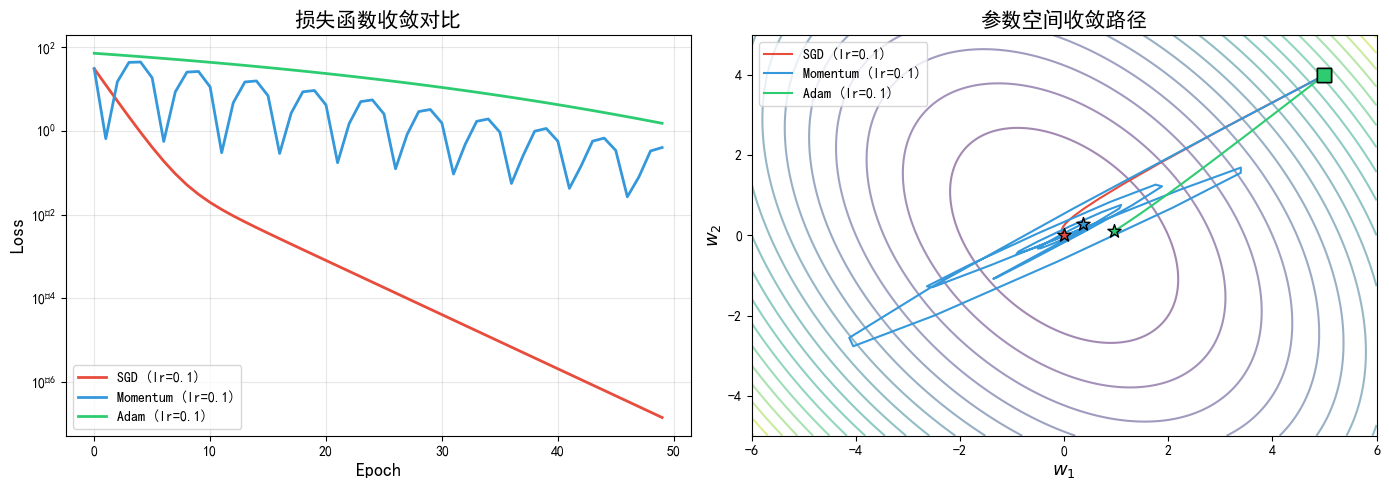


关键观察:
  - SGD: 收敛最慢，路径呈锯齿形
  - Momentum: 利用惯性加速收敛，减少震荡
  - Adam: 自适应学习率，收敛最快最稳


In [14]:
# ============================================
# 运行对比实验
# ============================================

optimizers = {
    'SGD (lr=0.1)': SGD(lr=0.1),
    'Momentum (lr=0.1)': Momentum(lr=0.1, beta=0.9),
    'Adam (lr=0.1)': AdamOptimizer(lr=0.1),
}

w_init = np.array([5.0, 4.0])
epochs = 50

results = {}
for name, opt in optimizers.items():
    w = w_init.copy()
    losses = []
    w_history = [w.copy()]
    
    for epoch in range(epochs):
        grad = quadratic_gradient(w)
        w = opt.step(w, grad)
        loss = quadratic_loss(w)
        losses.append(loss)
        w_history.append(w.copy())
    
    results[name] = {'losses': losses, 'w_history': np.array(w_history)}
    print(f"{name:>25} | 最终损失: {losses[-1]:.6f} | 最终 w: [{w[0]:.4f}, {w[1]:.4f}]")

# ============================================
# 可视化对比
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失曲线
ax1 = axes[0]
colors_opt = ['#e74c3c', '#3498db', '#2ecc71']
for (name, data), color in zip(results.items(), colors_opt):
    ax1.plot(data['losses'], '-', color=color, linewidth=2, label=name)
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Loss', fontsize=13)
ax1.set_title('损失函数收敛对比', fontsize=15, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 右图：参数空间路径
ax2 = axes[1]
w1_r = np.linspace(-6, 6, 200)
w2_r = np.linspace(-5, 5, 200)
W1_g, W2_g = np.meshgrid(w1_r, w2_r)
L_g = 0.5 * (3*W1_g**2 + 2*W1_g*W2_g + 2*W2_g**2)
ax2.contour(W1_g, W2_g, L_g, levels=20, cmap='viridis', alpha=0.5)

for (name, data), color in zip(results.items(), colors_opt):
    wh = data['w_history']
    ax2.plot(wh[:, 0], wh[:, 1], '-', color=color, linewidth=1.5, label=name)
    ax2.scatter(wh[0, 0], wh[0, 1], c=color, s=100, marker='s', edgecolors='black', zorder=5)
    ax2.scatter(wh[-1, 0], wh[-1, 1], c=color, s=100, marker='*', edgecolors='black', zorder=5)

ax2.set_xlabel('$w_1$', fontsize=13)
ax2.set_ylabel('$w_2$', fontsize=13)
ax2.set_title('参数空间收敛路径', fontsize=15, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n关键观察:")
print("  - SGD: 收敛最慢，路径呈锯齿形")
print("  - Momentum: 利用惯性加速收敛，减少震荡")
print("  - Adam: 自适应学习率，收敛最快最稳")

### 8.3 学习率调度策略可视化

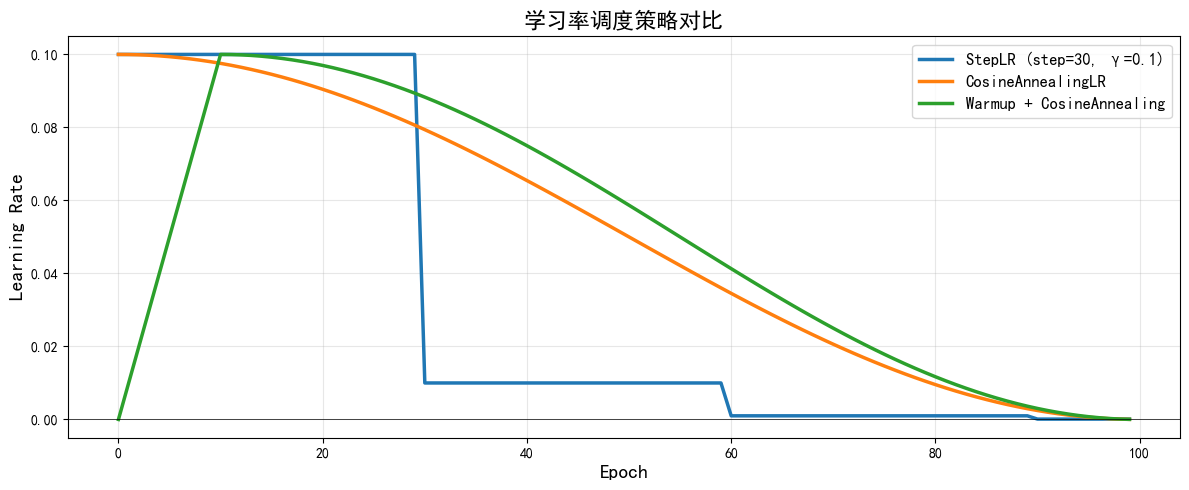

学习率调度策略特点:
  - StepLR: 在特定 epoch 将学习率乘以 γ，呈阶梯状下降
  - CosineAnnealing: 学习率按余弦函数平滑衰减到最小值
  - Warmup+Cosine: 训练初期先线性增大学习率（避免不稳定），再余弦衰减


In [15]:
# ============================================
# 学习率调度策略
# ============================================

def step_lr(epoch, lr_init=0.1, gamma=0.1, step_size=30):
    """阶梯衰减"""
    return lr_init * (gamma ** (epoch // step_size))

def cosine_lr(epoch, lr_max=0.1, lr_min=0, T_max=100):
    """余弦退火"""
    return lr_min + (lr_max - lr_min) / 2 * (1 + np.cos(epoch / T_max * np.pi))

def warmup_cosine_lr(epoch, lr_max=0.1, lr_min=0, T_max=100, T_warmup=10):
    """预热 + 余弦退火"""
    if epoch < T_warmup:
        return lr_max * epoch / T_warmup
    else:
        return cosine_lr(epoch - T_warmup, lr_max, lr_min, T_max - T_warmup)

# 计算各策略的学习率
epochs_range = np.arange(100)
lr_step = [step_lr(e) for e in epochs_range]
lr_cosine = [cosine_lr(e) for e in epochs_range]
lr_warmup_cosine = [warmup_cosine_lr(e) for e in epochs_range]

# 可视化
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(epochs_range, lr_step, '-', linewidth=2.5, label='StepLR (step=30, γ=0.1)')
ax.plot(epochs_range, lr_cosine, '-', linewidth=2.5, label='CosineAnnealingLR')
ax.plot(epochs_range, lr_warmup_cosine, '-', linewidth=2.5, label='Warmup + CosineAnnealing')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Learning Rate', fontsize=14)
ax.set_title('学习率调度策略对比', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("学习率调度策略特点:")
print("  - StepLR: 在特定 epoch 将学习率乘以 γ，呈阶梯状下降")
print("  - CosineAnnealing: 学习率按余弦函数平滑衰减到最小值")
print("  - Warmup+Cosine: 训练初期先线性增大学习率（避免不稳定），再余弦衰减")

---

## 📝 练习题

### 题目 1：概念辨析

**Q1.** 请从噪声程度、收敛速度、内存消耗三个维度对比 BGD、SGD 和 Mini-batch GD。

<details>
<summary>点击查看答案</summary>

| 维度 | BGD | SGD | Mini-batch GD |
|------|-----|-----|---------------|
| 噪声程度 | 无噪声 | 噪声最大 | 中等噪声 |
| 收敛速度 | 最慢 | 每步最快，但路径曲折 | 中等 |
| 内存消耗 | 最大（需加载全部数据） | 最小（1个样本） | 中等 |

</details>

### 题目 2：动量法推导

**Q2.** 写出动量法的更新公式，并解释为什么动量能帮助跳出局部最小值。

<details>
<summary>点击查看答案</summary>

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \eta \cdot \nabla_\theta L$$
$$\theta_{t+1} = \theta_t - \mathbf{v}_t$$

当参数陷入局部最小值时，虽然梯度为零（或很小），但之前积累的速度 $\mathbf{v}_t$ 不为零，因此参数仍会继续移动，有可能越过局部最小值到达更优的区域。

</details>

### 题目 3：Adam 算法

**Q3.** Adam 优化器中的偏差校正为什么要除以 $1 - \beta^t$？如果不做校正会有什么问题？

<details>
<summary>点击查看答案</summary>

由于 $\mathbf{m}_0 = 0, \mathbf{v}_0 = 0$，在训练初期，$\mathbf{m}_t$ 和 $\mathbf{v}_t$ 都偏向于 0：

$$\mathbb{E}[\mathbf{m}_t] = (1-\beta_1^t) \cdot \mu$$

除以 $1-\beta_1^t$ 后得到无偏估计。如果不校正，训练初期有效学习率会偏小，导致收敛缓慢。

</details>

### 题目 4：竞赛真题风格

**Q4.** 关于 Adam 优化器，以下说法错误的是（ ）

A. Adam 结合了 Momentum 和 RMSprop 的思想
B. Adam 中 $\beta_1$ 控制一阶矩的衰减率
C. Adam 的偏差校正在训练初期最重要，后期影响很小
D. Adam 中所有参数共享同一个学习率

<details>
<summary>点击查看答案</summary>

**答案：D**

Adam 的核心优势就是**每个参数有自适应的学习率**：
$$\eta_{\text{eff},i} = \frac{\eta}{\sqrt{\hat{v}_{t,i}}+\epsilon}$$
不同的 $\hat{v}_{t,i}$ 导致不同的有效学习率。A、B、C 均正确。

</details>

### 题目 5：编程题

**Q5.** 修改 Adam 优化器代码，将其改为 AdamW（添加解耦的权重衰减）。比较在有噪声的二次函数上 Adam 和 AdamW 的表现差异。

<details>
<summary>点击查看参考答案</summary>

```python
class AdamW:
    def __init__(self, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.wd = weight_decay
        self.m = None
        self.v = None
        self.t = 0
    
    def step(self, w, grad):
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        # 解耦的权重衰减
        w = w - self.lr * self.wd * w
        return w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
```

</details>
